# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [3]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 50
FEATURE_PREFIXES = ['genre_']  # kw_: TMDB post-release kullanıcı etiketleri

BASE_FEATURES = [
    'budget_log', 'runtime',
    # 'popularity', 'vote_average', 'vote_count',  # post-release
    'num_companies', 'num_countries', 'num_genres',
    # 'tagline_length', 'overview_length',          # gri alan — TMDB kayıt zamanı belirsiz
    'is_major_studio', 'is_english', 'is_us_production',
    # 'has_homepage',    # gri alan — TMDB kayıt zamanı belirsiz
    # 'has_postcredit',  # post-release
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (27 adet)

| Grup | Özellikler |
|------|-----------|
| Sayısal / meta (5) | `budget_log`, `runtime`, `num_companies`, `num_countries`, `num_genres` |
| Binary flags (3) | `is_major_studio`, `is_english`, `is_us_production` |
| Tür (19) | `genre_Action` … `genre_Western` |

#### Kullanılmayan Özellikler

| Özellik | Gerekçe |
|---------|---------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra oluşur |
| `has_postcredit` | Ancak filmi izleyen biri tarafından bilinebilir |
| `kw_murder`, `kw_violence`, `kw_revenge` vb. | TMDB kullanıcı etiketleri — film çıktıktan sonra eklenir |
| `tagline_length`, `overview_length`, `has_homepage` | Kavramsal olarak pre-release; ancak TMDB'ye ne zaman girildiği doğrulanamaz |
| `kw_sequel`, `kw_based_on_novel`, `kw_3d` vb. | Kavramsal olarak pre-release; ancak TMDB keyword'leri post-release eklenmiş olabilir |


### Veri Hazırlama *(dokunma)*

In [4]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols

df_model = df[FEATURES + [TARGET]].dropna()
X        = df_model[FEATURES]
y        = df_model[TARGET]

if TASK_TYPE == 'timeseries':
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=stratify, random_state=RANDOM_STATE
    )

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}')
print(f'Test     : {len(X_test):,}')
print(f'Özellik  : {len(FEATURES)}')

Dataset  : data/tmdb_model.csv
Task     : binary
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,580
Test     : 646
Özellik  : 27


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260418_1512  |  task: binary


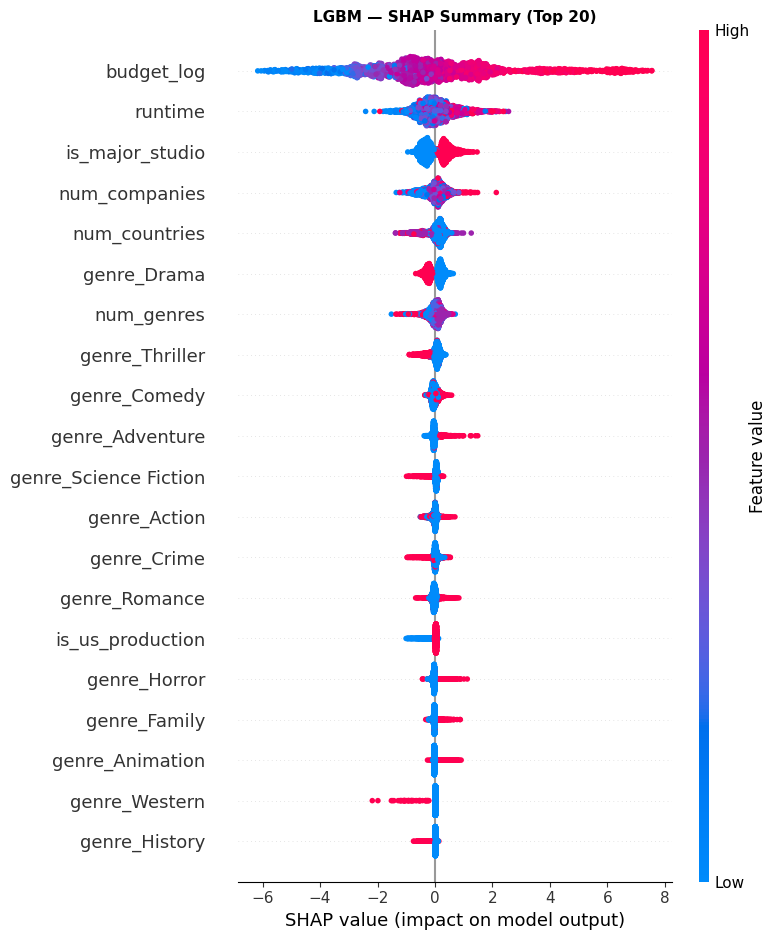

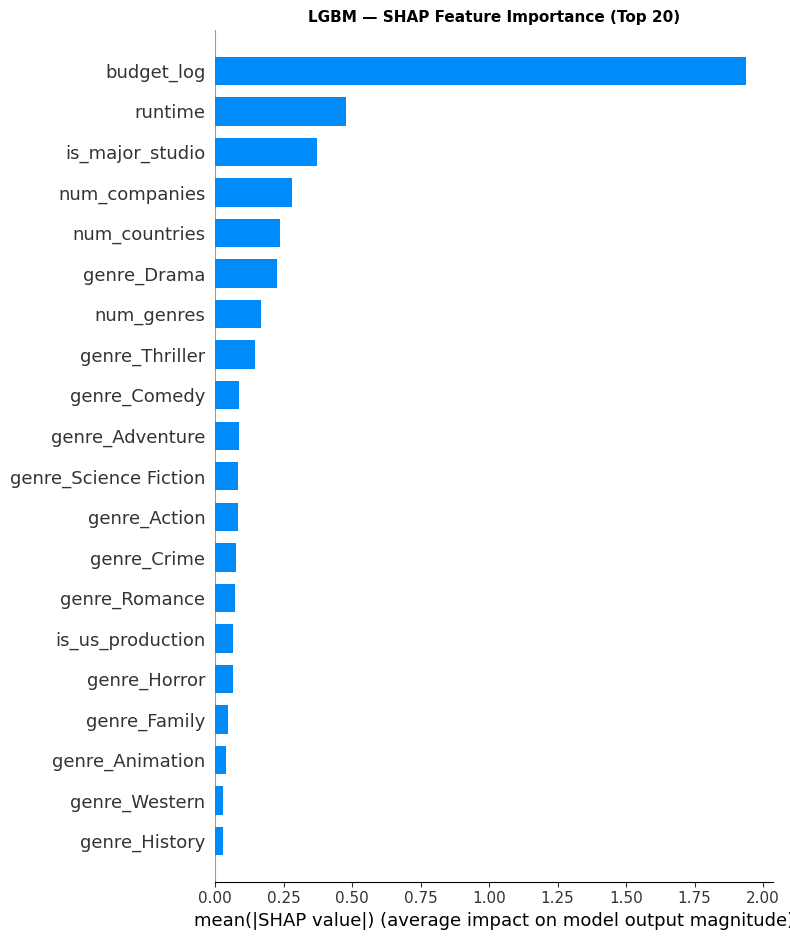

  ✓ baseline_lgbm_20260418_1512                        train=0.999  val=0.747  gap=+0.252
🏃 View run baseline_lgbm_20260418_1512 at: http://localhost:5000/#/experiments/1/runs/cdf081c95ae14077b781aae0d5ab024a
🧪 View experiment at: http://localhost:5000/#/experiments/1


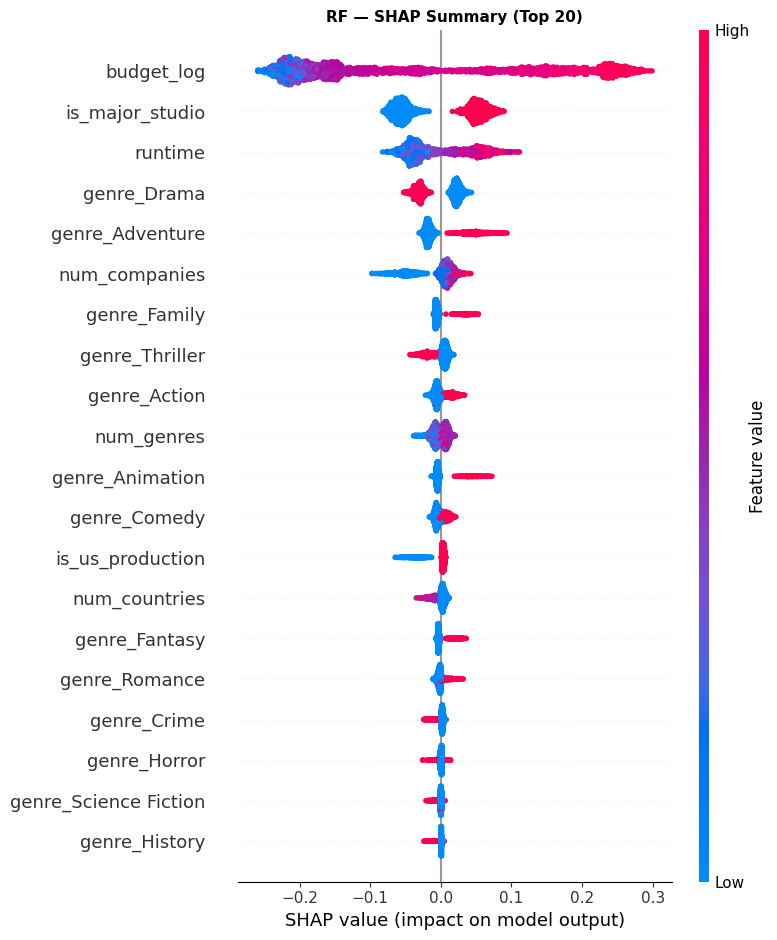

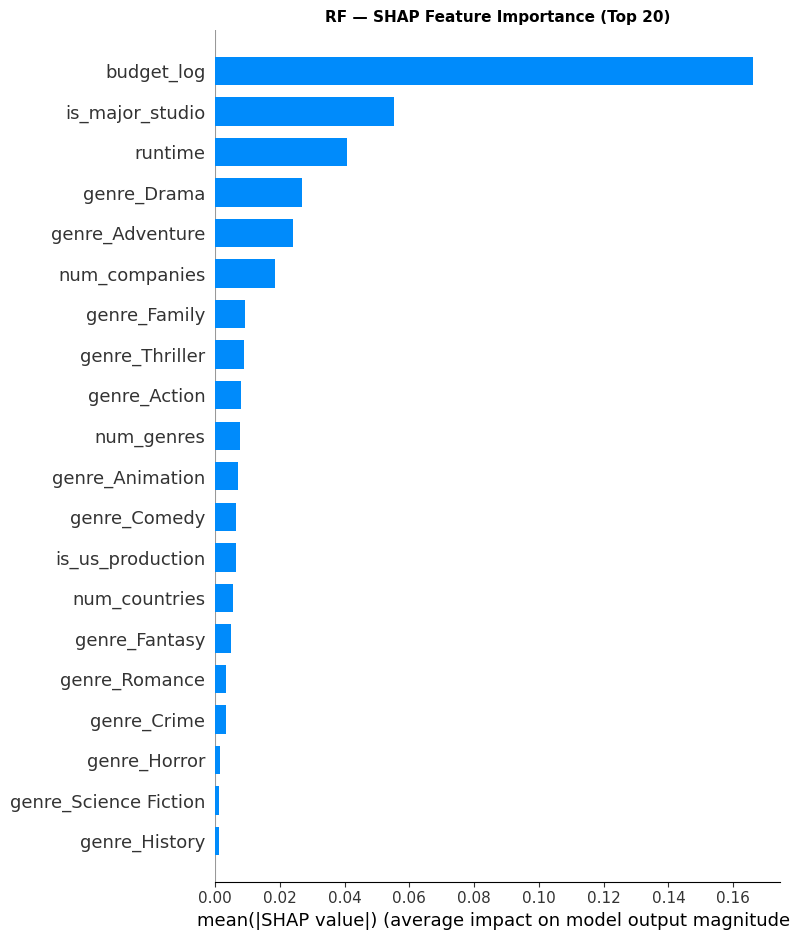

  ✓ baseline_rf_20260418_1512                          train=0.844  val=0.775  gap=+0.069
🏃 View run baseline_rf_20260418_1512 at: http://localhost:5000/#/experiments/1/runs/2e4e918c743b48cb92b05f87a389b095
🧪 View experiment at: http://localhost:5000/#/experiments/1


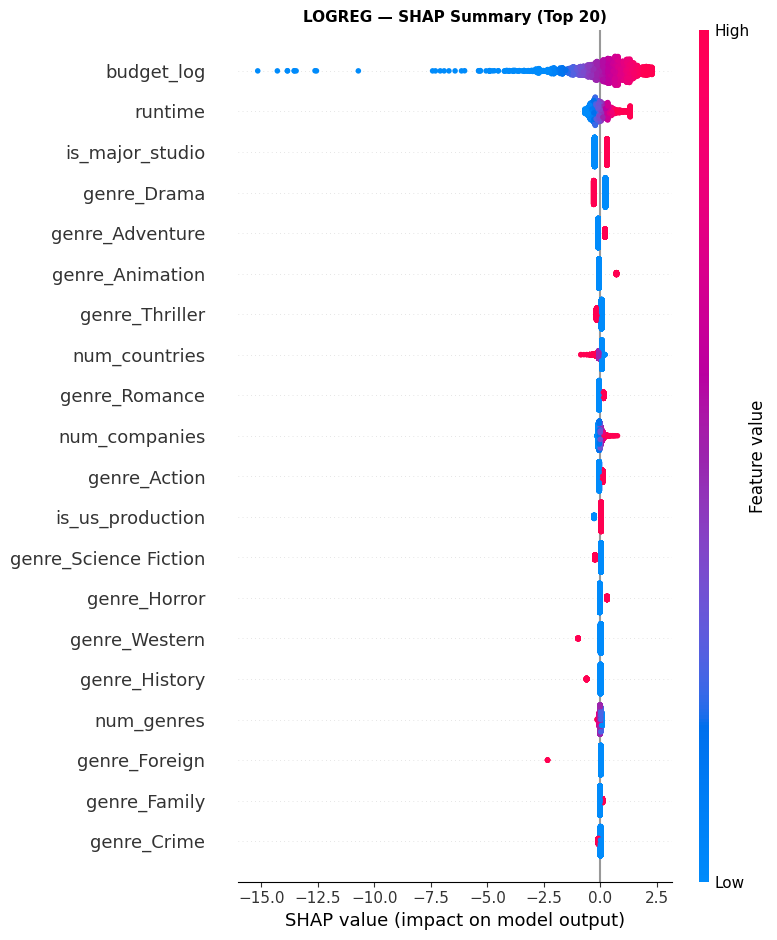

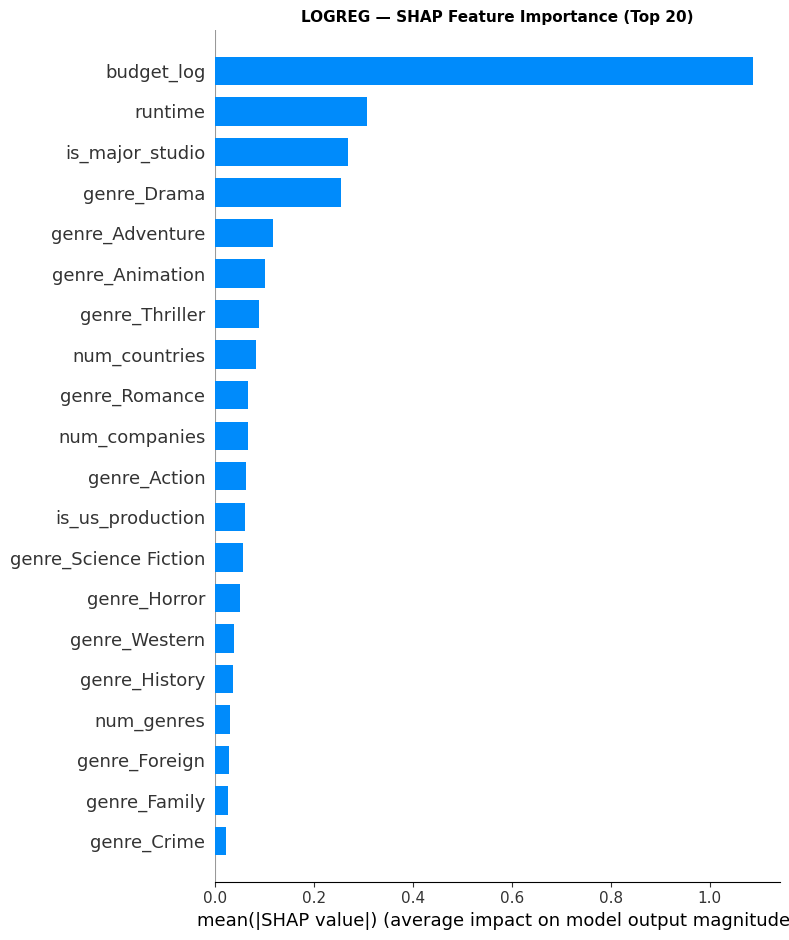

  ✓ baseline_logreg_20260418_1513                      train=0.774  val=0.759  gap=+0.015
🏃 View run baseline_logreg_20260418_1513 at: http://localhost:5000/#/experiments/1/runs/ae49ee6ed25348b9876456c0f64c1b20
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260418_1512 at: http://localhost:5000/#/experiments/1/runs/c01cd060406043379866298b3049dfd3
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [5]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.829,0.641,0.685,0.603,0.747
rf,0.847,0.688,0.655,0.725,0.775
logreg,0.836,0.687,0.619,0.773,0.759



🏆 En iyi model: rf  (avg_prec=0.775)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/6f745d59ab214869b079959a303f1e86
🧪 View experiment at: http://localhost:5000/#/experiments/1


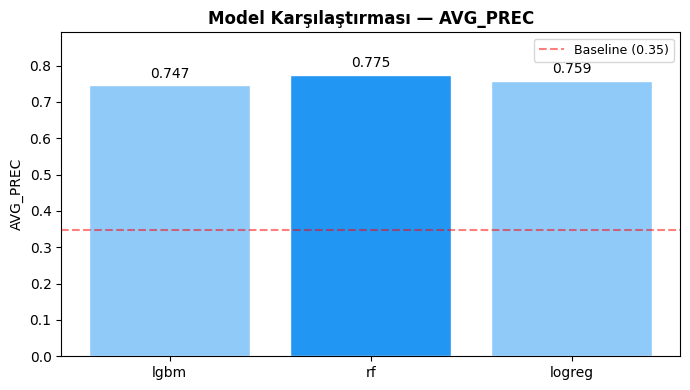


=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,0.999,0.747,0.252
rf,0.844,0.775,0.069
logreg,0.774,0.759,0.015


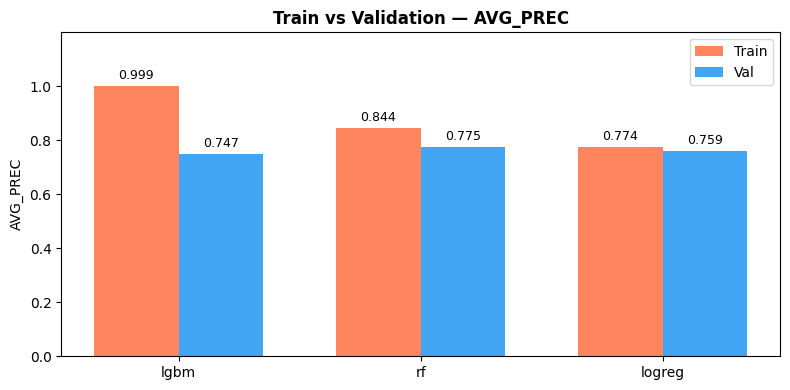

  ⚠️  lgbm: ciddi overfit (gap=0.252 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg'] — en iyi: rf


In [6]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [7]:
from src.automl import tune_all_models

best_model, best = tune_all_models(
    results      = results,
    X            = X_train,
    y            = y_train,
    task_type    = TASK_TYPE,
    n_trials     = N_TRIALS,
    max_gap      = 0.10,
)


── Tuning: rf  (baseline=0.7754  min_improvement=0.0233) ──
Optuna başlıyor — model: rf  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7754
  Tuned     avg_prec: 0.7798
  İyileşme : +0.0045

  En iyi parametreler:
    n_estimators: 208
    max_depth: 9
    min_samples_leaf: 5
    max_features: sqrt
  Train-val gap: 0.0918  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260418_1514 at: http://localhost:5000/#/experiments/1/runs/f3b1612b4e0e4aa5a8356b6d590e3518
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  — rf: iyileşme yetersiz (+0.0044 < 0.0233) — elendi

── Tuning: logreg  (baseline=0.7590  min_improvement=0.0253) ──
Optuna başlıyor — model: logreg  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7590
  Tuned     avg_prec: 0.7606
  İyileşme : +0.0017

  En iyi parametreler:
    C: 1.8167526837517824
  Train-val gap: 0.0158  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_logreg_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/8634f0140ad84eceab1a1343b664338c
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0016 < 0.0253) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7473
  Tuned     avg_prec: 0.7765
  İyileşme : +0.0292

  En iyi parametreler:
    n_estimators: 432
    learning_rate: 0.011384001308562295
    num_leaves: 18
    min_child_samples: 52
    reg_alpha: 0.00011105672867310765
    reg_lambda: 0.000473598727599572
    subsample: 0.6745232059029459
    colsample_bytree: 0.5407349983126768
  Train-val gap: 0.0736  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/59d861bba66340b8904e4b2166e92fc9
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7765 ≤ 0.7798) — best model değişmedi

✓ tune_all_models tamamlandı — best: rf  (avg_prec=0.7798)


## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       421
           1       0.73      0.74      0.74       225

    accuracy                           0.82       646
   macro avg       0.80      0.80      0.80       646
weighted avg       0.82      0.82      0.82       646


=== Test Metrikleri ===
  PR-AUC      : 0.8012
  ROC-AUC     : 0.8709
  F1          : 0.7361
  Precision   : 0.7345
  Recall      : 0.7378

=== RF — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.775,0.801,0.026
ROC-AUC,0.847,0.871,0.024
F1,0.688,0.736,0.048
Precision,0.655,0.735,0.080
Recall,0.725,0.738,0.013


🏃 View run test_eval_rf_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/de53fc3cea124a10bd6c43749239da05
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


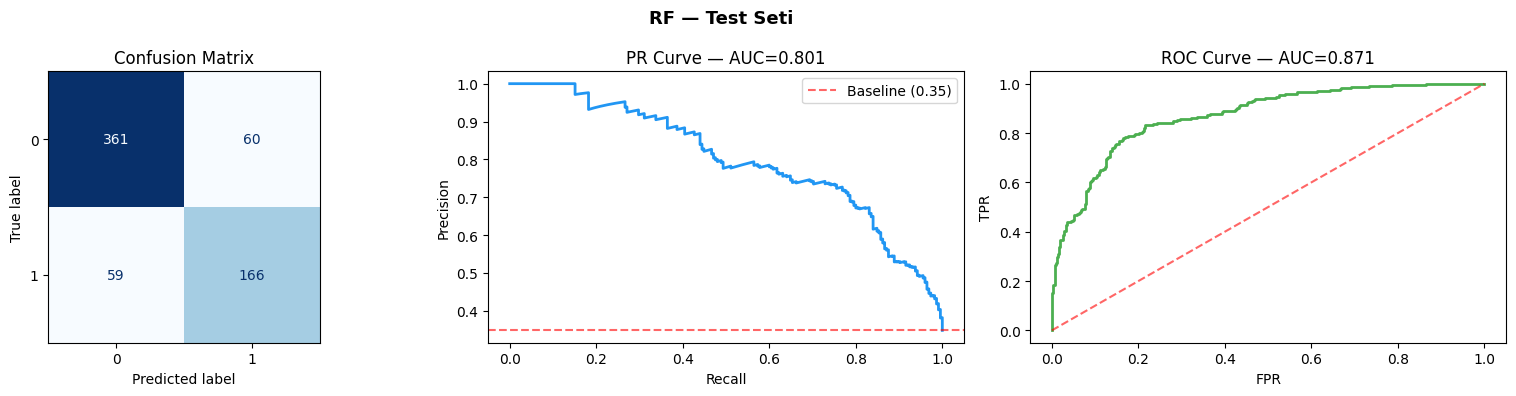

In [8]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
)


## 6 — Rapor

In [9]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260418_151542.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260418_151542.md
🏃 View run report_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/283740af23c941c6a7cb5cc59b2b6065
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-18 15:15  
**Task:** binary  
**Ana Metrik:** avg_prec  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 27  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| logreg | 0.759 | 0.836 | 0.687 | 0.619 | 0.773 |
| rf | 0.775 | 0.847 | 0.688 | 0.655 | 0.725 |
| lgbm | 0.747 | 0.829 | 0.641 | 0.685 | 0.603 |

---

## Tuning

- **lgbm** — Baseline avg_prec: 0.747 → Tuned: 0.776 (İyileşme: 0.029)
- **logreg** — Baseline avg_prec: 0.759 → Tuned: 0.761 (İyileşme: 0.002)
- **rf** — Baseline avg_prec: 0.775 → Tuned: 0.780 (İyileşme: 0.004)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| F1 | 0.736 |
| PRECISION | 0.735 |
| RECALL | 0.738 |
| ROC_AUC | 0.871 |
| PR_AUC | 0.801 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [10]:
import numpy as np
from sklearn.ensemble import VotingClassifier, StackingClassifier

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')

✓ Base model factory hazır  |  imbalance_ratio: 1.870


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       421
           1       0.71      0.71      0.71       225

    accuracy                           0.80       646
   macro avg       0.78      0.78      0.78       646
weighted avg       0.80      0.80      0.80       646


=== Test Metrikleri ===
  PR-AUC      : 0.8028
  ROC-AUC     : 0.8690
  F1          : 0.7082
  Precision   : 0.7098
  Recall      : 0.7067

=== VOTING_ENSEMBLE — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.775,0.803,0.028
ROC-AUC,0.847,0.869,0.022
F1,0.688,0.708,0.020
Precision,0.655,0.710,0.055
Recall,0.725,0.707,-0.018


🏃 View run test_eval_voting_ensemble_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/fb3f677d753341338c82b66d2e01a205
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


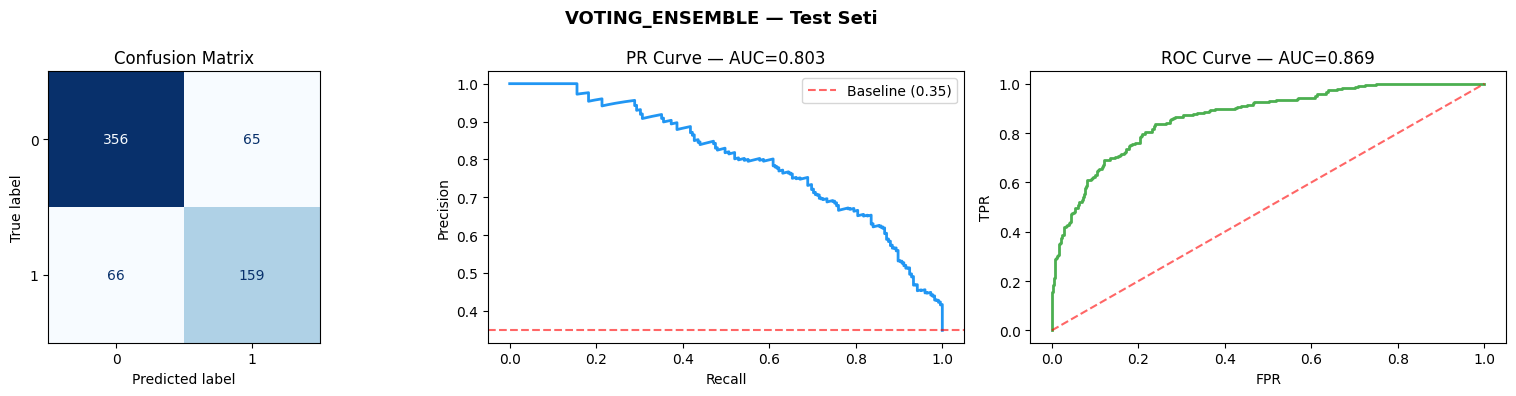

In [11]:
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm',   make_lgbm()),
        ('rf',     make_rf()),
        ('logreg', make_logreg()),
    ],
    voting='soft',
    weights=[2, 1, 1],  # LGBM baseline'da en güçlü → daha yüksek ağırlık
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)

voting_metrics = evaluate_test(
    voting_clf, X_test, y_test, TASK_TYPE, 'voting_ensemble',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
)

### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       421
           1       0.78      0.63      0.69       225

    accuracy                           0.81       646
   macro avg       0.80      0.77      0.78       646
weighted avg       0.81      0.81      0.80       646


=== Test Metrikleri ===
  PR-AUC      : 0.8019
  ROC-AUC     : 0.8722
  F1          : 0.6946
  Precision   : 0.7790
  Recall      : 0.6267

=== STACKING — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.775,0.802,0.027
ROC-AUC,0.847,0.872,0.025
F1,0.688,0.695,0.007
Precision,0.655,0.779,0.124
Recall,0.725,0.627,-0.098


🏃 View run test_eval_stacking_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/cc85dffb1be04776838cc614894ec833
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


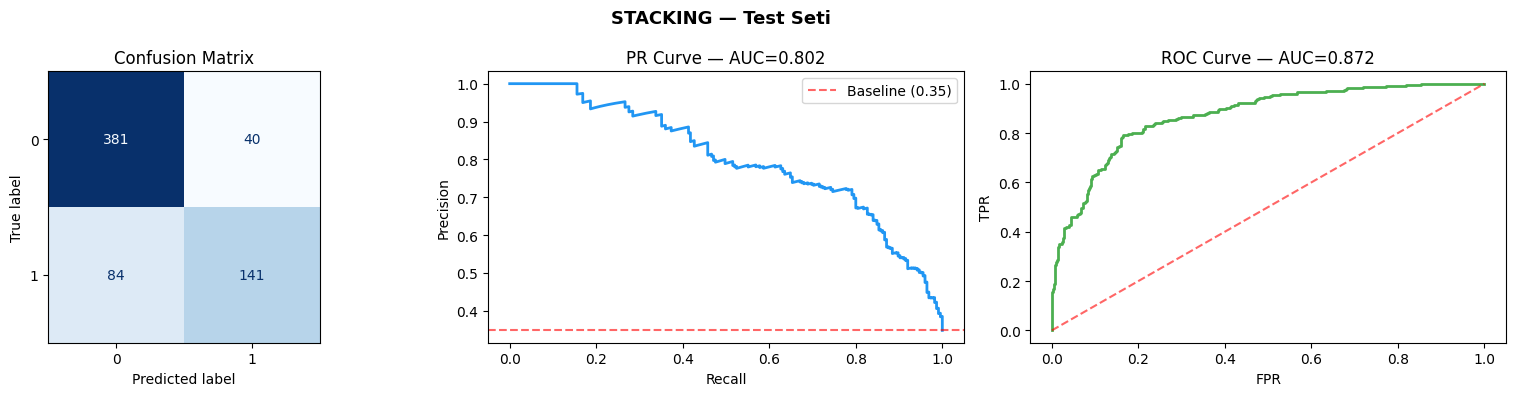

In [12]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm', make_lgbm()),
        ('rf',   make_rf()),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)

stacking_metrics = evaluate_test(
    stacking_clf, X_test, y_test, TASK_TYPE, 'stacking',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
)

### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [13]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

✓ BlendingEnsemble sınıfı tanımlandı


              precision    recall  f1-score   support

           0       0.81      0.90      0.86       421
           1       0.78      0.61      0.68       225

    accuracy                           0.80       646
   macro avg       0.79      0.76      0.77       646
weighted avg       0.80      0.80      0.80       646


=== Test Metrikleri ===
  PR-AUC      : 0.8023
  ROC-AUC     : 0.8723
  F1          : 0.6849
  Precision   : 0.7753
  Recall      : 0.6133

=== BLENDING — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.775,0.802,0.027
ROC-AUC,0.847,0.872,0.025
F1,0.688,0.685,-0.003
Precision,0.655,0.775,0.120
Recall,0.725,0.613,-0.112


🏃 View run test_eval_blending_20260418_1515 at: http://localhost:5000/#/experiments/1/runs/2d32e0d161984519916cd94be9529eea
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


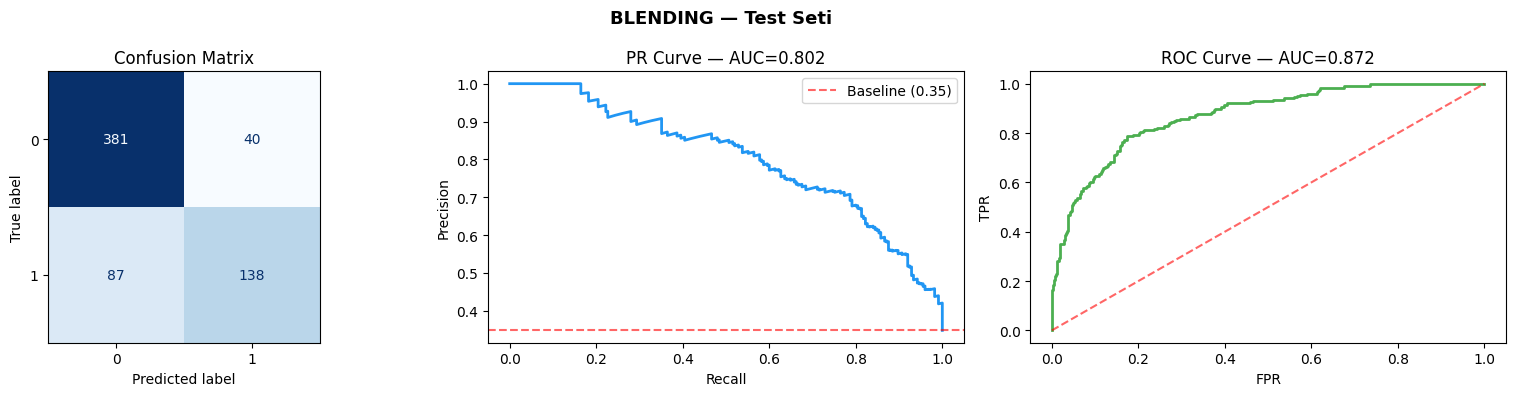

In [14]:
blending_clf = BlendingEnsemble(
    base_models=[
        ('lgbm',   make_lgbm()),
        ('rf',     make_rf()),
        ('logreg', make_logreg()),
    ],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)

blending_metrics = evaluate_test(
    blending_clf, X_test, y_test, TASK_TYPE, 'blending',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
)

### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması ===


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
best_single (rf),0.8012,0.8709,0.7361,0.7345,0.7378
voting,0.8028,0.8690,0.7082,0.7098,0.7067
stacking,0.8019,0.8722,0.6946,0.7790,0.6267
blending,0.8023,0.8723,0.6849,0.7753,0.6133


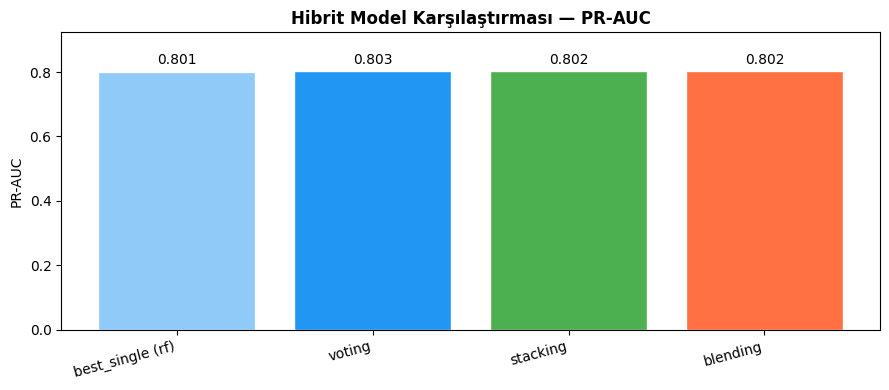

In [15]:
metric_col = 'PR-AUC'
hybrid_results = {
    f'best_single ({best})': test_metrics,
    'voting':                voting_metrics,
    'stacking':              stacking_metrics,
    'blending':              blending_metrics,
}

rows = []
for name, m in hybrid_results.items():
    rows.append({'Model': name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index('Model')
print('=== Hibrit Model Karşılaştırması ===')
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_results.values()]
labels = list(hybrid_results.keys())
colors = ['#90CAF9', '#2196F3', '#4CAF50', '#FF7043']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title(f'Hibrit Model Karşılaştırması — {metric_col}', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Final Model Seçimi

In [16]:
all_candidates = {
    f'best_single ({best})': (best_model,    test_metrics),
    'voting':                (voting_clf,    voting_metrics),
    'stacking':              (stacking_clf,  stacking_metrics),
    'blending':              (blending_clf,  blending_metrics),
}

main_metric_key = 'F1'
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_metrics = all_candidates[final_name][1]

print('=== Final Model ===')
print(f'  Model     : {final_name}')
for k, v in final_metrics.items():
    print(f'  {k:<12}: {v:.4f}')


=== Final Model ===
  Model     : best_single (rf)
  PR-AUC      : 0.8012
  ROC-AUC     : 0.8709
  F1          : 0.7361
  Precision   : 0.7345
  Recall      : 0.7378
